# Context corner plot of GW170817

In [1]:
import matplotlib.pyplot as plt
import bilby
import pandas as pd
import numpy as np
import matplotlib.lines as mlines
import corner
import h5py

In [2]:
# TaylorF2Ecck
result1 = bilby.result.read_in_result("../result_files/TF2Ecck_3PN_bayeswave.hdf5")
chirp_mass1 = result1.posterior["chirp_mass"].values
mass_ratio1 =  result1.posterior["mass_ratio"].values
e01 = result1.posterior["eccentricity"].values
m11 = (chirp_mass1*(1+mass_ratio1)**(1/5))/mass_ratio1**(3/5)
m21 = chirp_mass1*mass_ratio1**(2/5)*(1+mass_ratio1)**(1/5)
mtot1 = m11 + m21
eta1 = (m11*m21)/(mtot1**2)

# TaylorF2Ecc 3p5PN + Spin
result2 = bilby.result.read_in_result("../result_files/TF2Ecc_3p5PN_bayeswave_spin.hdf5")
chirp_mass2 = result2.posterior["chirp_mass"].values
mass_ratio2 =  result2.posterior["mass_ratio"].values
e02 = result2.posterior["eccentricity"].values
m12 = (chirp_mass2*(1+mass_ratio2)**(1/5))/mass_ratio2**(3/5)
m22 = chirp_mass2*mass_ratio2**(2/5)*(1+mass_ratio2)**(1/5)
mtot2 = m12 + m22
eta2 = (m12*m22)/(mtot2**2)

# TaylorF2Ecc 3p5PN + Spin LNB
result3 = h5py.File("../result_files/tf2_e_170817v2.hdf", "r")
m13_src = np.array(result3['samples']['srcmass1'])
m23_src = np.array(result3['samples']['srcmass2'])
idx = m13_src < m23_src
m13_src[idx], m23_src[idx] = m23_src[idx], m13_src[idx]
dl = np.array(result3['samples']['distance'])
# import astropy, convert dl to z, and convert mass to detector frame
from astropy.cosmology import Planck18
from astropy import units as u
# make a spline 
from scipy.interpolate import interp1d
z = np.linspace(0, 2, 1000)
dl_ = Planck18.luminosity_distance(z)
f = interp1d(dl_, z)
z = f(dl)
m13 = m13_src*(1+z)
m23 = m23_src*(1+z)
chirp_mass3 = (m13*m23)**(3/5) / (m13 + m23)**(1/5) 
mass_ratio3 = m23/m13
e03 = result3['samples']['eccentricity']
mtot3 = m13 + m23
eta3 = (m13*m23)/(mtot3**2)

# Pv2NRT
f = h5py.File('../result_files/GW170817_GWTC-1.hdf5', 'r')
events = f['IMRPhenomPv2NRT_lowSpin_posterior']
m10 = np.array(events['m1_detector_frame_Msun'])
m20 = np.array(events['m2_detector_frame_Msun'])
e04 = np.random.uniform(0.0, 0.0001, len(m10))
chirp_mass4 = ( (m10*m20)**(3/5) )/( (m10+m20)**(1/5) )
mass_ratio4 = m20/m10
mtot4 = m10 + m20
eta4 = (m10*m20)/(mtot4**2)

06:33 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
06:33 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


In [3]:
rng = np.random.default_rng(12345)
nsamples = np.min([len(chirp_mass1), len(chirp_mass2), len(chirp_mass3)])
data1 = np.transpose(np.array([chirp_mass1, mass_ratio1, mtot1, eta1, e01]))
df1 = pd.DataFrame(data1, columns=["chirp_mass", "mass_ratio", 'mtot', 'eta', "eccentricity"])
df1 = df1.sample(n=nsamples, random_state=rng)

data2 = np.transpose(np.array([chirp_mass2, mass_ratio2, mtot2, eta2, e02]))
df2 = pd.DataFrame(data2, columns=["chirp_mass", "mass_ratio", 'mtot', 'eta', "eccentricity"])
df2 = df2.sample(n=nsamples, random_state=rng)

data3 = np.transpose(np.array([chirp_mass3, mass_ratio3, mtot3, eta3, e03]))
df3 = pd.DataFrame(data3, columns=["chirp_mass", "mass_ratio", 'mtot', 'eta', "eccentricity"])
df3 = df3.sample(n=nsamples, random_state=rng)

data4 = np.transpose(np.array([chirp_mass4, mass_ratio4, mtot4, eta4, e04]))
df4 = pd.DataFrame(data4, columns=["chirp_mass", "mass_ratio", 'mtot', 'eta', "eccentricity"])
df4 = df4.sample(n=nsamples, random_state=rng)

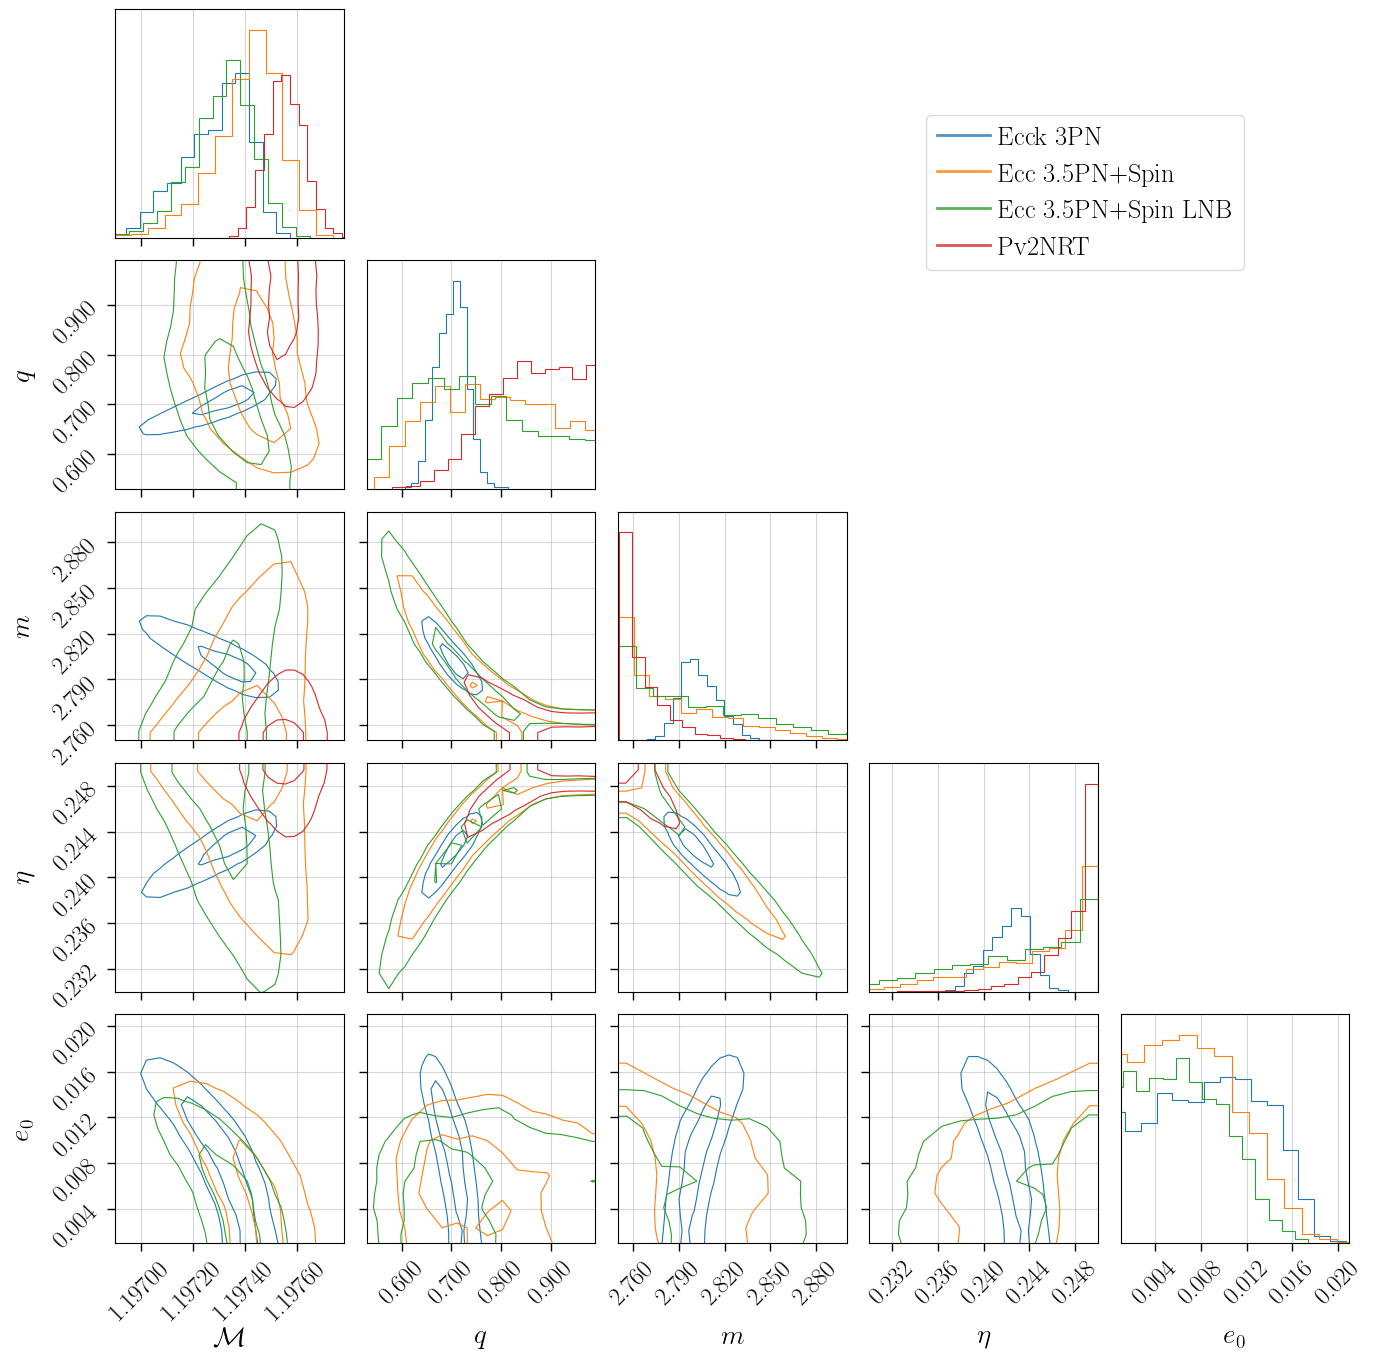

In [4]:
ndim = 5
size_axis_label = 20
size_tick_label = 18
size_legend_label = 19

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": size_tick_label,
    "axes.labelsize": size_axis_label,
    "axes.titlesize": size_axis_label,
    "xtick.labelsize": size_tick_label,
    "ytick.labelsize": size_tick_label,
    "legend.fontsize": size_legend_label,
    "figure.titlesize": size_axis_label
})
fig, axes = plt.subplots(ndim, ndim, figsize=(14, 14), gridspec_kw={"hspace": 0.1, "wspace": 0.1})

corner.corner(df1, fig=fig,color = 'C0', bins=15, smooth=0.80, plot_datapoints=False, plot_density=False, contourf_kwargs= dict(alpha=0.4), levels=(0.393,0.864), hist_kwargs={'linewidth': 0.8}, contour_kwargs={'linewidths': 0.8}, label_kwargs={'fontsize': size_axis_label})

corner.corner(df2, fig=fig, color='C1', bins=15, smooth=0.80, plot_datapoints=False, plot_density=False, contourf_kwargs= dict(alpha=0.4), levels=(0.393,0.864), hist_kwargs={'linewidth': 0.8}, contour_kwargs={'linewidths': 0.8},)

corner.corner(df3, fig=fig, color='C2', bins=15, smooth=0.80, plot_datapoints=False, plot_density=False, contourf_kwargs= dict(alpha=0.4), levels=(0.393,0.864), hist_kwargs={'linewidth': 0.8}, contour_kwargs={'linewidths': 0.8})

corner.corner(df4, fig=fig, color='C3', bins=15, smooth=0.80, plot_datapoints=False, plot_density=False, contourf_kwargs= dict(alpha=0.4), levels=(0.393,0.864), hist_kwargs={'linewidth': 0.8}, contour_kwargs={'linewidths': 0.8})

for i in range(ndim):
    title = axes[i, i].get_title()
    if " = " in title:
        axes[i, i].set_title(title.split(" = ", 1)[1], fontsize=size_legend_label)

# x-axis tick labels
# Mc
axes[4, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.5f' % x))
min_mc = 1.19690
max_mc = 1.19778
axes[4,0].set_xlim(min_mc, max_mc)
axes[3,0].set_xlim(min_mc, max_mc)
axes[2,0].set_xlim(min_mc, max_mc)
axes[1,0].set_xlim(min_mc, max_mc)
axes[0,0].set_xlim(min_mc, max_mc)
# q
axes[4, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
min_q = 0.53
max_q = 0.99
axes[4,1].set_xlim(min_q, max_q)
axes[3,1].set_xlim(min_q, max_q)
axes[2,1].set_xlim(min_q, max_q)
axes[1,1].set_xlim(min_q, max_q)
# m
axes[4, 2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
min_m = 2.750
max_m = 2.90
axes[4,2].set_xlim(min_m, max_m)
axes[3,2].set_xlim(min_m, max_m)
axes[2,2].set_xlim(min_m, max_m)
# eta
axes[4, 3].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
min_eta = 0.23
max_eta = 0.250
axes[4,3].set_xlim(min_eta, max_eta)
axes[3,3].set_xlim(min_eta, max_eta)
axes[3,3].set_xlim(min_eta, max_eta)
# e0
axes[4, 4].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
min_e0 = 0.001
max_e0 = 0.021
axes[4,4].set_xlim(min_e0, max_e0)


# y-axis tick labels
axes[4, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '%.3f' % y))
axes[4,0].set_ylim(min_e0, max_e0)
axes[4,1].set_ylim(min_e0, max_e0)
axes[4,2].set_ylim(min_e0, max_e0)
axes[4,3].set_ylim(min_e0, max_e0)
axes[3, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '%.3f' % y))
axes[3,0].set_ylim(min_eta, max_eta)
axes[3,1].set_ylim(min_eta, max_eta)
axes[3,2].set_ylim(min_eta, max_eta)
axes[2, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '%.3f' % y))
axes[2,0].set_ylim(min_m, max_m)
axes[2,1].set_ylim(min_m, max_m)
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '%.3f' % y))
axes[1,0].set_ylim(min_q, max_q)

for ax in axes.flat:
    ax.tick_params(axis='both', which='both', labelsize=size_tick_label)

# x-axis labels
axes[4,0].set_xlabel(r'$\mathcal{M}$', labelpad=2, fontsize=size_axis_label)
axes[4,1].set_xlabel(r'$q$', labelpad=11, fontsize=size_axis_label)
axes[4,2].set_xlabel(r'$m$', labelpad=11, fontsize=size_axis_label)
axes[4,3].set_xlabel(r'$\eta$', labelpad=11, fontsize=size_axis_label)
axes[4,4].set_xlabel(r'$e_0$', labelpad=11, fontsize=size_axis_label)
# y-axis labels
axes[4, 0].set_ylabel(r'$e_0$', labelpad=11, fontsize=size_axis_label)
axes[3, 0].set_ylabel(r'$\eta$', labelpad=11, fontsize=size_axis_label)
axes[2, 0].set_ylabel(r'$m$', labelpad=11, fontsize=size_axis_label)
axes[1, 0].set_ylabel(r'$q$', labelpad=11, fontsize=size_axis_label)

# add grid
for i in range(ndim):
    for j in range(ndim):
        if axes[i, j] is not None:
            axes[i, j].grid(True, which="both", ls="-", alpha=0.5)

# add legend with line colors
blue_line = mlines.Line2D([], [], color='C0', label='Ecck 3PN')
orange_line = mlines.Line2D([], [], color='C1', label='Ecc 3.5PN+Spin')
green_line = mlines.Line2D([], [], color='C2', label='Ecc 3.5PN+Spin LNB')
red_line = mlines.Line2D([], [], color='C3', label='Pv2NRT')
handles = [blue_line, orange_line, green_line, red_line]
labels = [h.get_label() for h in handles] 
#fig.legend(handles=handles, labels=labels, bbox_to_anchor=(0., 0.9, 0.9, .0), ncol=1, fontsize=size_legend_label)
legend = fig.legend(handles=handles, labels=labels, handlelength=2, loc='upper right', bbox_to_anchor=(0., 0.9, 0.9, .0), frameon=True, fontsize=size_legend_label, edgecolor='lightgray')
# # rounded box for legend
legend.get_frame().set_boxstyle('Round', pad=0.0, rounding_size=0.2)
# Modify line width for legend entries
for handle in legend.get_lines():
    handle.set_linewidth(2)
    handle.set_alpha(0.8)

plt.savefig("GW170817_with_LNB.pdf", bbox_inches="tight", dpi=300)
plt.show()